#### 1. Setup

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr


np.random.seed(40)
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

#### 2. Load Dataset

In [2]:
df = pd.read_csv("insurance.csv")

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


In [4]:
df.shape

(1338, 7)

In [5]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

#### 3. Data Quality Checks

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [7]:
# Identifying and seperating the numerical and categorical column
num_cols = ["age", "bmi", "children", "charges"]
cat_cols = ["sex", "smoker", "region"]

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: ['age', 'bmi', 'children', 'charges']
Categorical Columns: ['sex', 'smoker', 'region']


In [8]:
print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())

print("*"*50)

print("\nData Types:")
print(df.dtypes)

print("*"*50)

print("\nUnique Values per Column:")
print(df.nunique())

Shape: (1338, 7)

Column Names:
 ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']
**************************************************

Data Types:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object
**************************************************

Unique Values per Column:
age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64


In [9]:
# DEscriptive statistics of numerical column
df[num_cols].describe()

,age,bmi,children,charges
count,1338.000,1338.000,1338.000,1338.000
mean,39.207,30.663,1.095,13270.422
std,14.050,6.098,1.205,12110.011
min,18.000,15.960,0.000,1121.874
25%,27.000,26.296,0.000,4740.287
50%,39.000,30.400,1.000,9382.033
75%,51.000,34.694,2.000,16639.913
max,64.000,53.130,5.000,63770.428


**Missing values - analysis**

In [10]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
None


In [11]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [12]:
missing_count =df.isna().sum().sort_values(ascending=False)
missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent
})

print("Missing values summary:")
print(missing_summary)

Missing values summary:
          missing_count  missing_percent
age                   0            0.000
sex                   0            0.000
bmi                   0            0.000
children              0            0.000
smoker                0            0.000
region                0            0.000
charges               0            0.000


**No missing values in the dataset. still need to verify encoded missing values**

ex: -999, 999, unknown

In [13]:
for col in df.columns:
    print(df[col].value_counts())
    print("*"*50)

age
18    69
19    68
46    29
52    29
48    29
20    29
45    29
47    29
51    29
50    29
28    28
25    28
23    28
27    28
22    28
26    28
24    28
21    28
53    28
54    28
49    28
31    27
30    27
41    27
40    27
43    27
44    27
29    27
42    27
33    26
32    26
56    26
34    26
55    26
57    26
37    25
59    25
35    25
38    25
36    25
58    25
39    25
60    23
62    23
63    23
61    23
64    22
Name: count, dtype: int64
**************************************************
sex
male      676
female    662
Name: count, dtype: int64
**************************************************
bmi
32.300    13
28.310     9
28.880     8
34.100     8
30.800     8
          ..
53.130     1
39.710     1
32.870     1
44.700     1
30.970     1
Name: count, Length: 548, dtype: int64
**************************************************
children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64
**************************************************
smoker
no 

There is no encoded missing values in the dataset

**Duplicates**

In [14]:
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()

print("Number of duplicate rows:", num_duplicates)
print("Duplicated rows:\n", df[duplicate_mask])

# If there is need to remove duplicates
df_no_duplicate = df.drop_duplicates()
print("Shape after dropping duplicates:", df_no_duplicate.shape)

Number of duplicate rows: 1
Duplicated rows:
      age   sex    bmi  children smoker     region  charges
581   19  male 30.590         0     no  northwest 1639.563
Shape after dropping duplicates: (1337, 7)


In [15]:
# List of columns
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

**Data type Validation**

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [17]:
expected_types = {
    "age": "int64",
    "sex": "object",
    "bmi":"float64",
    "children":"int64",
    "smoker": "object",
    "region":"object",
    "charges": "float64"
}

print("Data Type validation:")
for col, expected in expected_types.items():
    if col in df.columns:
        actual=df[col].dtype
        print(f"{col}: actual={actual}, expected={expected}")

Data Type validation:
age: actual=int64, expected=int64
sex: actual=str, expected=object
bmi: actual=float64, expected=float64
children: actual=int64, expected=int64
smoker: actual=str, expected=object
region: actual=str, expected=object
charges: actual=float64, expected=float64


**Constant and quasi Constant columns**

In [18]:
n_rows = len(df)
nunique = df.nunique()

constant_cols = nunique[nunique == 1].index.tolist()
print("Constant columns:", constant_cols)

# Quasi constant: top value more than 95%
quasi_constant_cols = []

for col in df.columns:
    top_freq = df[col].value_counts(normalize=True, dropna=False).values[0]
    if top_freq > 0.95 and col not in constant_cols:
        quasi_constant_cols.append[col]

print("Quasi constant columns (top value more than 95 percent):", quasi_constant_cols)

Constant columns:

 []
Quasi constant columns (top value more than 95 percent): []


NOTE: No constant quasi column

**ID Like columns**

In [19]:
id_like_cols = []

for col in df.columns:
    if df[col].nunique(dropna=False) == n_rows:
        id_like_cols.append(col)

print("ID like columns:", id_like_cols)

ID like columns: []


- skipping string inconsitencies as it is not critical and value counts doesn't seem to show any in string coumn
- no Null Columns


**High Zero Columns (Numeric)**

In [20]:
zero_share = {}

for col in num_cols:
    zero_share[col] = (df[col] == 0).mean()

zero_share_series = pd.Series(zero_share).sort_values(ascending=False)
zero_share_series

high_zero_threshold = 0.8  # 80% or more zeros
high_zero_columns = zero_share_series[zero_share_series >= high_zero_threshold]
print("Numeric columns with many zeros:")
high_zero_columns

Numeric columns with many zeros:


Series([], dtype: float64)

#### 4. Univariate Analysis



Numerical Features - Analysis

**1. Descriptive statistics - summary**

In [21]:
print("Summary Statistics:")
df[num_cols].describe()

Summary Statistics:


,age,bmi,children,charges
count,1338.000,1338.000,1338.000,1338.000
mean,39.207,30.663,1.095,13270.422
std,14.050,6.098,1.205,12110.011
min,18.000,15.960,0.000,1121.874
25%,27.000,26.296,0.000,4740.287
50%,39.000,30.400,1.000,9382.033
75%,51.000,34.694,2.000,16639.913
max,64.000,53.130,5.000,63770.428


**2. Central Tendency -  ean, Median, Mode**

In [22]:
print("Mean:")
print(df[num_cols].mean())

print("*"*50)

print("Median:")
print(df[num_cols].median())

print("*"*50)

print("Mode:")
print(df[num_cols].mode().iloc[0])

Mean:
age           39.207
bmi           30.663
children       1.095
charges    13270.422
dtype: float64
**************************************************
Median:
age          39.000
bmi          30.400
children      1.000
charges    9382.033
dtype: float64
**************************************************
Mode:
age          18.000
bmi          32.300
children      0.000
charges    1639.563
Name: 0, dtype: float64


**3. Measure of spread - variance and standard deviation**

In [23]:
print("Variance:")
print(df[num_cols].var())

print("*"*50)

print("Standard Deviation:")
print(df[num_cols].std())

Variance:
age              197.401
bmi               37.188
children           1.453
charges    146652372.153
dtype: float64
**************************************************
Standard Deviation:
age           14.050
bmi            6.098
children       1.205
charges    12110.011
dtype: float64


**4. Skewness and kurtosis**

In [24]:
print("SKewness:")
print(df[num_cols].skew())

print("\nKurtosis:")
print(df[num_cols].kurtosis())

SKewness:
age        0.056
bmi        0.284
children   0.938
charges    1.516
dtype: float64

Kurtosis:
age        -1.245
bmi        -0.051
children    0.202
charges     1.606
dtype: float64


**5. Histograms - Distribution**

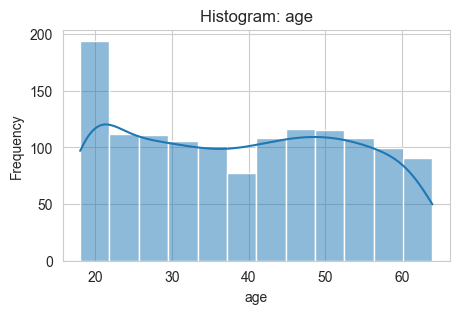

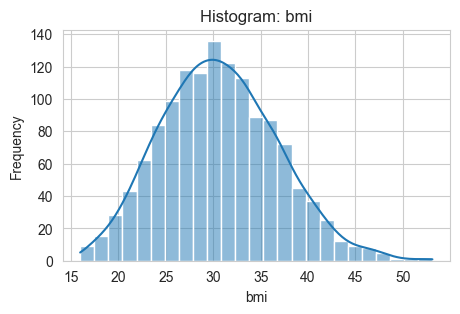

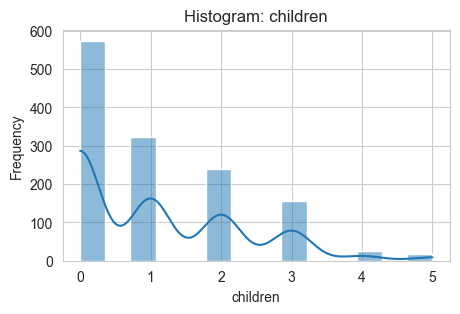

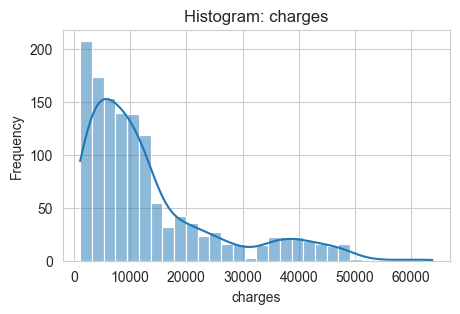

In [25]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col], kde=True)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

- Skewness in children and charges column

**6. Boxplot - Outliers**

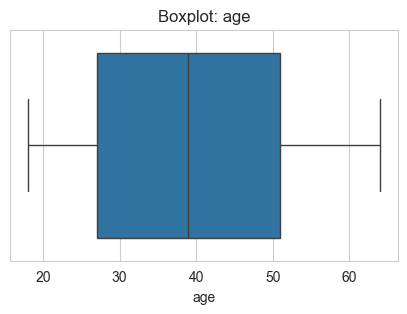

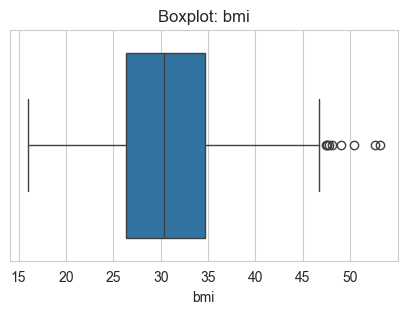

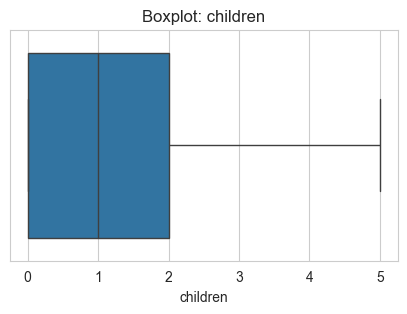

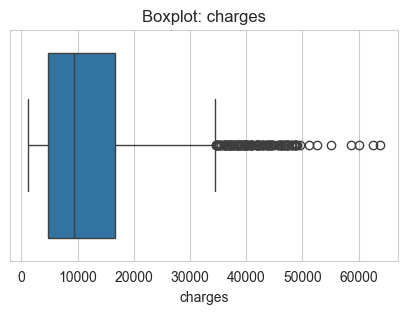

In [26]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot: {col}")
    plt.xlabel(col)
    plt.show()

infrences - there are everal outliers in "charges" column (target). The ML Model would not be able to provide accurate predictions throughout the range. Transformatons should be applied in pre-processing step to address this

Categorical Features - Analysis

In [27]:
print(cat_cols)

['sex', 'smoker', 'region']


In [28]:
df[cat_cols].head()

,sex,smoker,region
0,female,yes,southwest
1,male,no,southeast
2,male,no,southeast
3,male,no,northwest
4,male,no,northwest


**1. Frequency Table**

In [29]:
for col in cat_cols:
    print(f"Frequency table for {col}")
    print(df[col].value_counts())
    print(f"Proportion for {col}")
    print(df[col].value_counts(normalize=True))
    print("*"*50)

Frequency table for sex
sex
male      676
female    662
Name: count, dtype: int64
Proportion for sex
sex
male     0.505
female   0.495
Name: proportion, dtype: float64
**************************************************
Frequency table for smoker
smoker
no     1064
yes     274
Name: count, dtype: int64
Proportion for smoker
smoker
no    0.795
yes   0.205
Name: proportion, dtype: float64
**************************************************
Frequency table for region
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64
Proportion for region
region
southeast   0.272
southwest   0.243
northwest   0.243
northeast   0.242
Name: proportion, dtype: float64
**************************************************


inference - There is imbalance in smoker column

**2. Countplot**

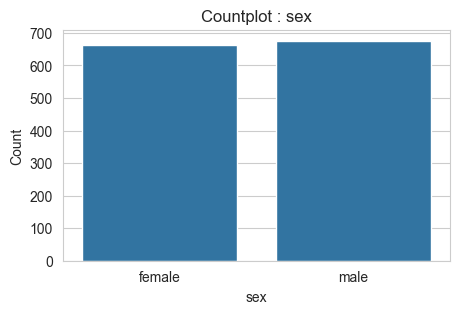

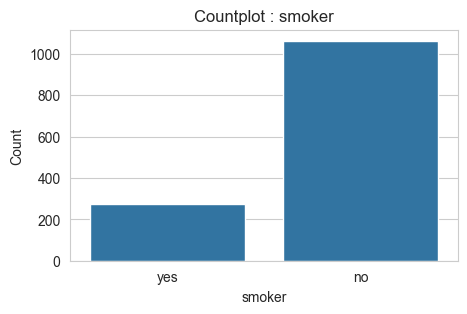

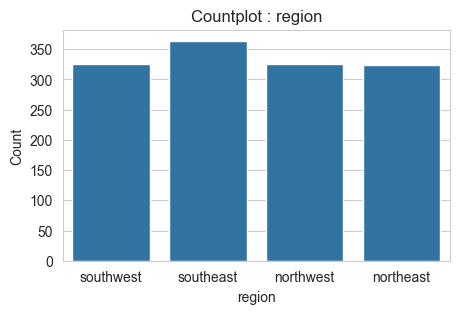

In [30]:
for col in cat_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(x=df[col])
    plt.title(f"Countplot : {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

#### 5. Bivariate Analysis

In [31]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


In [32]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [33]:
print("Numerica Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerica Columns: ['age', 'bmi', 'children', 'charges']
Categorical Columns: ['sex', 'smoker', 'region']


Numerical vs Numerical Features

**1. Scatter plot**

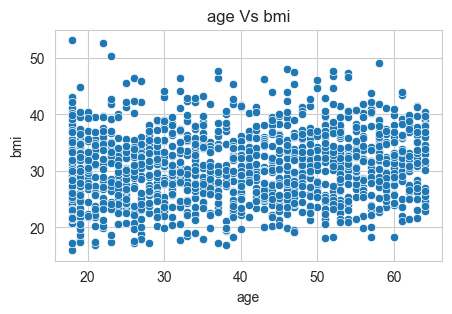

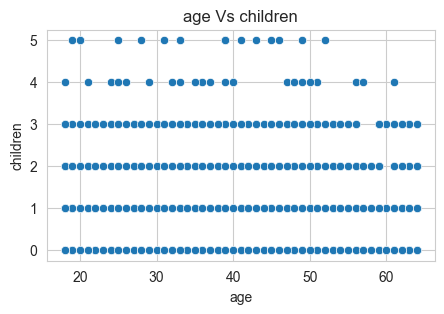

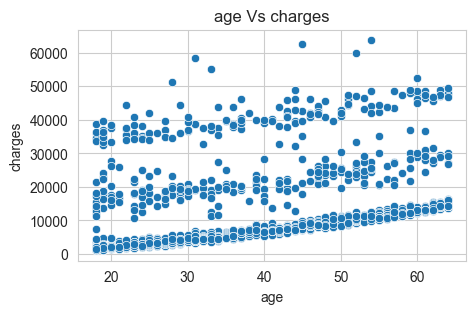

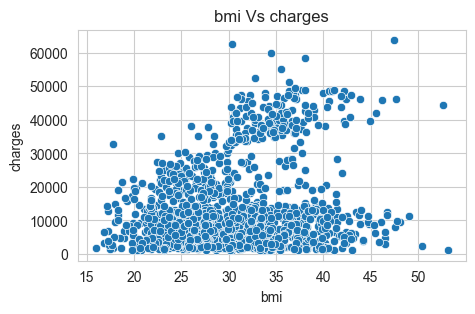

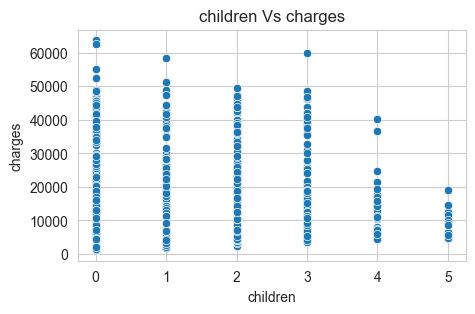

In [34]:
num_pairs =[
    ("age", "bmi"),
    ("age", "children"),
    ("age", "charges"),
    ("bmi", "charges"),
    ("children", "charges")
]

for x,y in num_pairs:
    plt.figure(figsize=(5,3))
    sns.scatterplot(x=df[x], y=df[y])
    plt.title(f"{x} Vs {y}")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.show()

inference: slight positive correlation between
- age vs charges
- BMI & charges

**2. Correlation Matrix**

In [35]:
print("Correlation Matrix:")
df[num_cols].corr()

Correlation Matrix:


,age,bmi,children,charges
age,1.000,0.109,0.042,0.299
bmi,0.109,1.000,0.013,0.198
children,0.042,0.013,1.000,0.068
charges,0.299,0.198,0.068,1.000


In [36]:
print("Pearson Correlation with fare:")
for col in num_cols:
    if col != "age":
        r,p = pearsonr(df[col], df["age"])
        print(f"{col} vs age: r={r:.3f}; p={p:.3f}")


# r, p: r -> corrleaton coefficient (-1 to +1); p-> small vat (0.05) -> strong confidence; high -> random coincidence

Pearson Correlation with fare:
bmi vs age: r=0.109; p=0.000
children vs age: r=0.042; p=0.120
charges vs age: r=0.299; p=0.000


- Slight positive correlation between chharges vs age
- Sight positive correlation between BMI and charges

**Numerical Vs Categorical Features**

1. Boxplots

In [37]:
print(num_cols)
print(cat_cols)

['age', 'bmi', 'children', 'charges']
['sex', 'smoker', 'region']


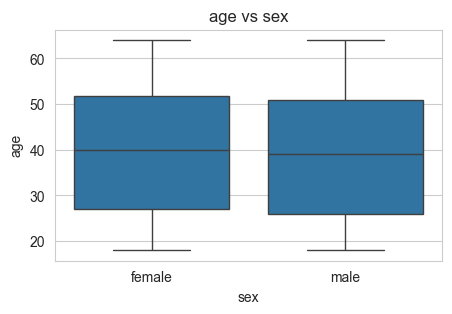

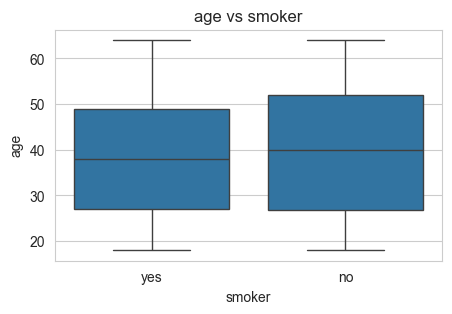

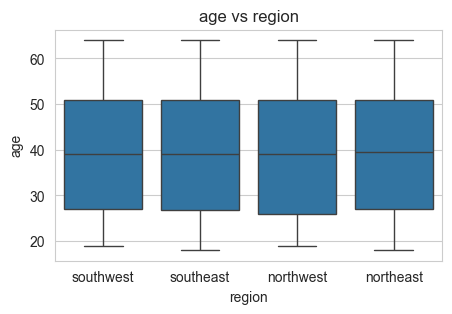

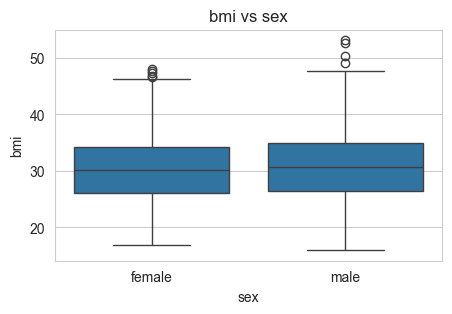

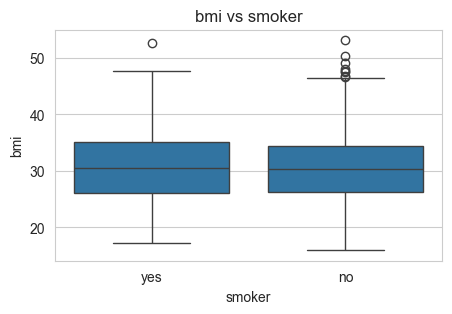

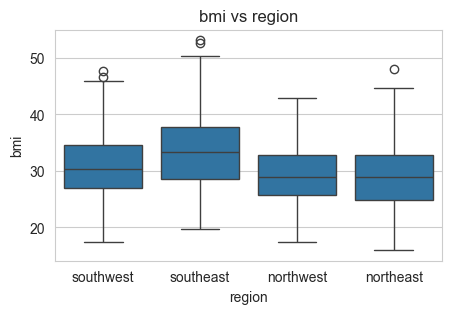

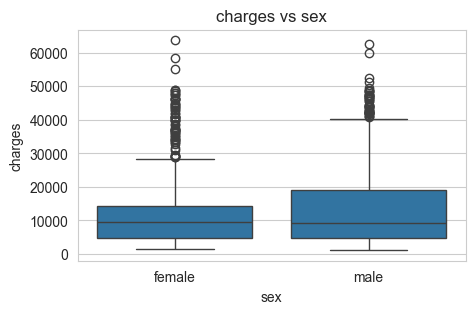

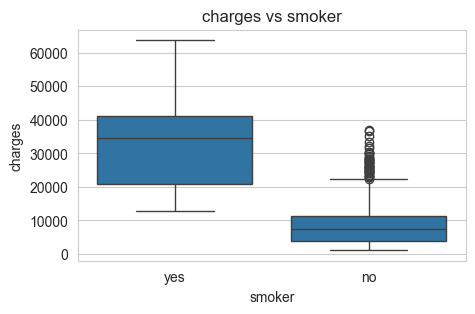

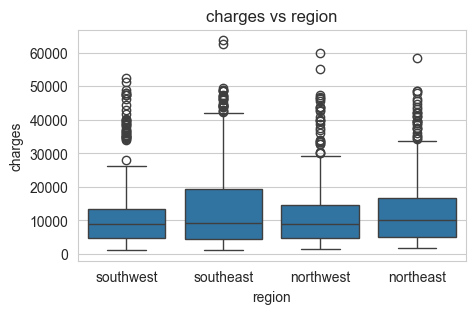

In [38]:
num_for_box = ["age", "bmi", "charges"]
cat_for_box = ["sex", "smoker", "region"]

for num in num_for_box:
    for cat in cat_for_box:
        plt.figure(figsize=(5,3))
        sns.boxplot(x=df[cat], y=df[num])
        plt.title(f"{num} vs {cat}")
        plt.xlabel(cat)
        plt.ylabel(num)
        plt.show()

inferences:
- insurance charges is very high for smokers compared to non-smokers
- more number of famale have lesser charges compared to male (maybe related to soker - if gender biased)
- median age of non-smoker slightly higher than smokers
- similar median charges across different regions

**2. Grouped Statistics**

In [39]:
df[num_cols + ["sex"]].groupby("sex").mean()

,age,bmi,children,charges
sex,,,,
female,39.503,30.378,1.074,12569.579
male,38.917,30.943,1.115,13956.751


In [40]:
for category in ["sex", "smoker", "region"]:
    print(df[num_cols + [category]].groupby(category).mean())
    print("*"*50)

          age    bmi  children   charges
sex                                     
female 39.503 30.378     1.074 12569.579
male   38.917 30.943     1.115 13956.751
**************************************************
          age    bmi  children   charges
smoker                                  
no     39.385 30.652     1.090  8434.268
yes    38.515 30.708     1.113 32050.232
**************************************************
             age    bmi  children   charges
region                                     
northeast 39.269 29.174     1.046 13406.385
northwest 39.197 29.200     1.148 12417.575
southeast 38.940 33.356     1.049 14735.411
southwest 39.455 30.597     1.142 12346.937
**************************************************


inferences:
- higher charges ofr smokers
- region based slight increase in carges

**Categorical Vs Categorical Features**

Crosstab

In [41]:
# Get combinations to play with
print("Crosstab: sex vs smoker")
print(pd.crosstab(df["sex"], df["smoker"]))

print("Crosstab: smoker Vs region")
print(pd.crosstab(df["smoker"], df["region"]))

Crosstab: sex vs smoker
smoker   no  yes
sex             
female  547  115
male    517  159
Crosstab: smoker Vs region
region  northeast  northwest  southeast  southwest
smoker                                            
no            257        267        273        267
yes            67         58         91         58


Countplot

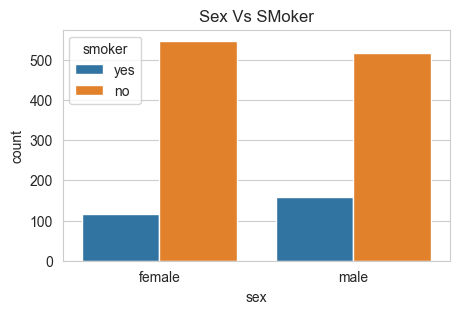

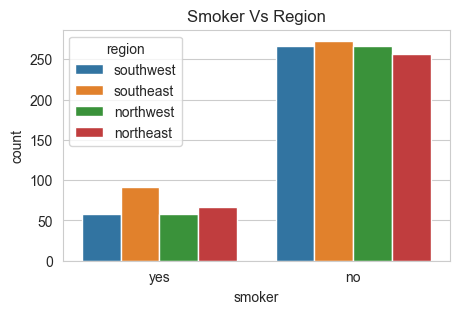

In [43]:
plt.figure(figsize=(5,3))
sns.countplot(x=df["sex"], hue=df["smoker"])
plt.title("Sex Vs SMoker")
plt.show()

plt.figure(figsize=(5,3))
sns.countplot(x=df["smoker"], hue=df["region"])
plt.title("Smoker Vs Region")
plt.show()

### 6. Multivariate Analysis

In [44]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


In [45]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [46]:
df.shape

(1338, 7)

In [47]:
print("Numerical COlumns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical COlumns: ['age', 'bmi', 'children', 'charges']
Categorical Columns: ['sex', 'smoker', 'region']


**Pair Plot**

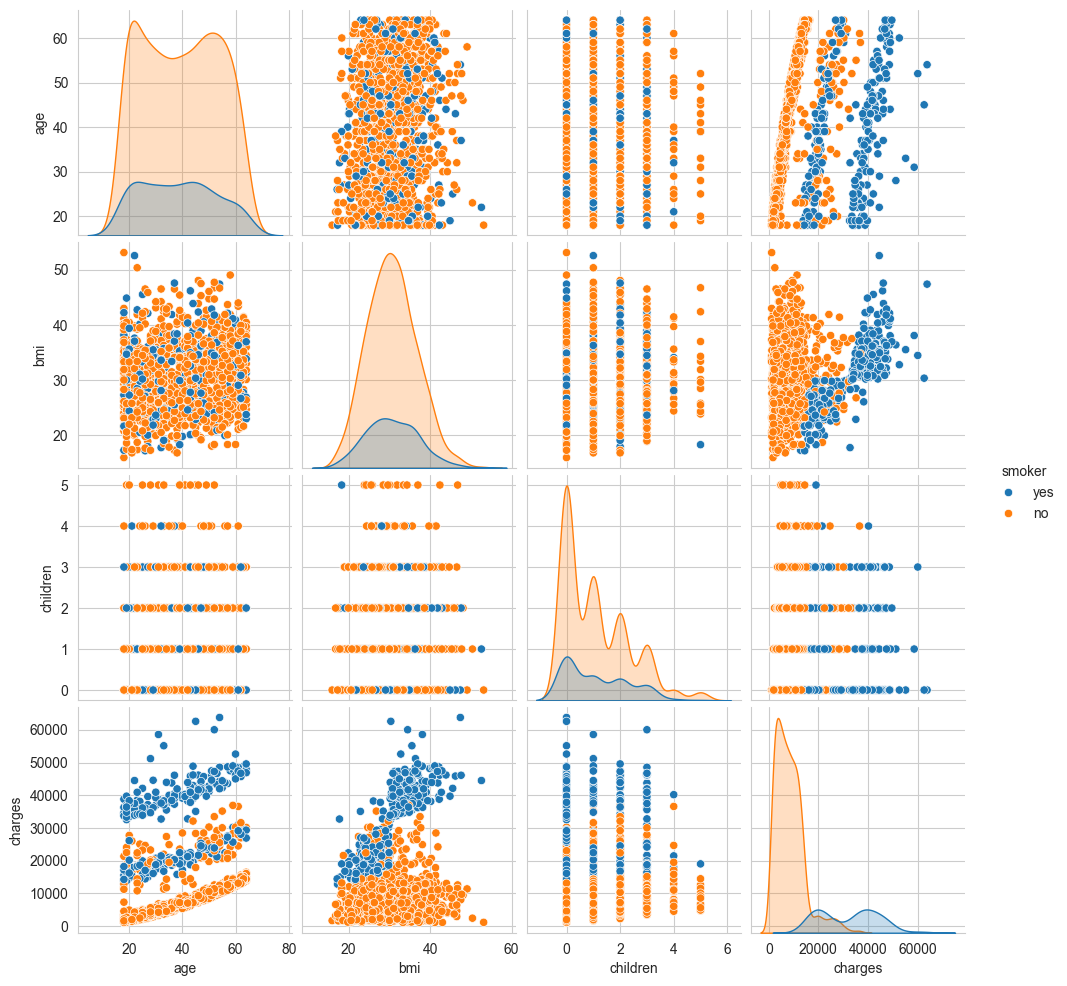

In [48]:
pairplot_cols = num_cols + ["smoker"]

df_pair = df[pairplot_cols].dropna()

sns.pairplot(df_pair, hue="smoker")
plt.show()

 - charges increase with age -  aspecially with smoker=yes; clear cluster visible
 - similar for bmi and charges (high charges for smokers with high bmi)

**Correlation Heatmap**

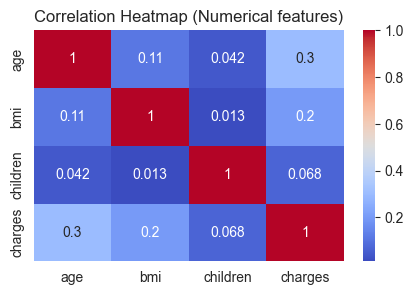

In [49]:
plt.figure(figsize=(5,3))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Numerical features)")
plt.show()

inference:
- No high (+ve) or (-ve) correlation
- No multi-collinearity

**Cluster Map**

<Figure size 500x300 with 0 Axes>

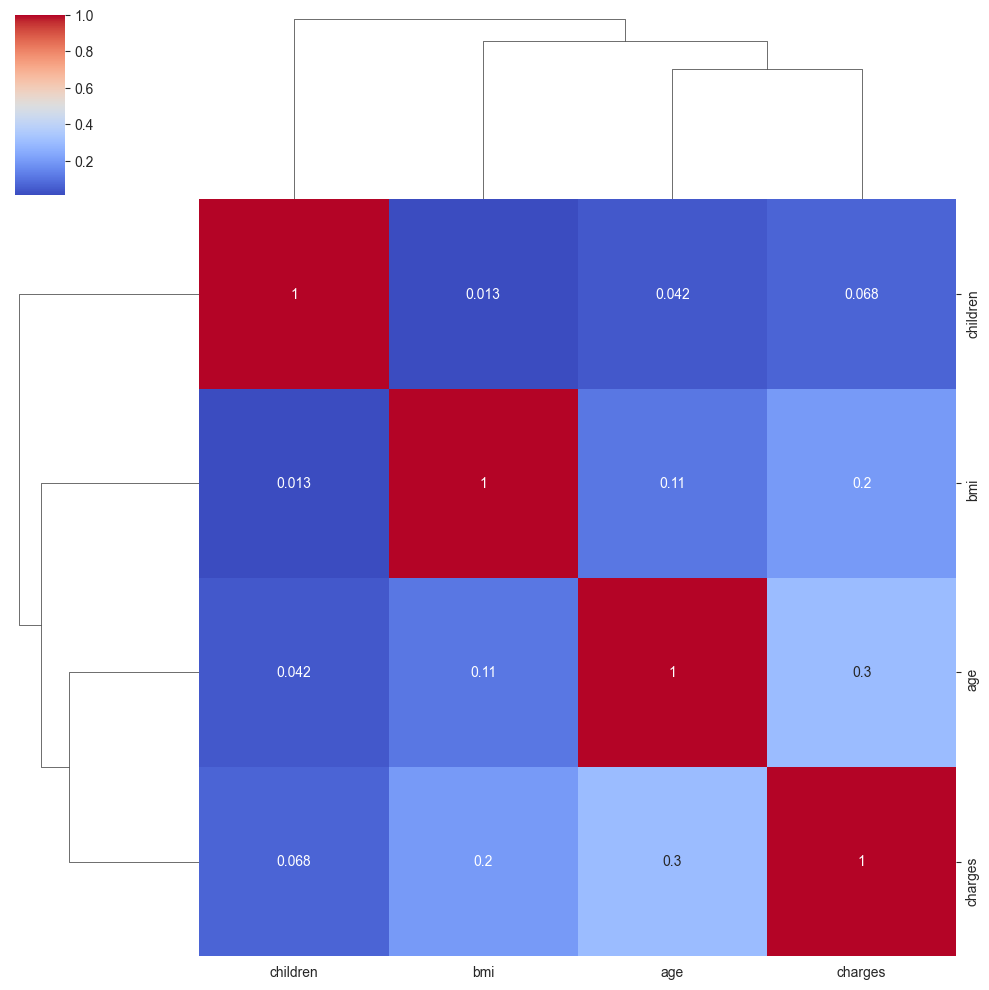

In [50]:
plt.figure(figsize=(5,3))
sns.clustermap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.show()

**Interaction and sub-group pattern**

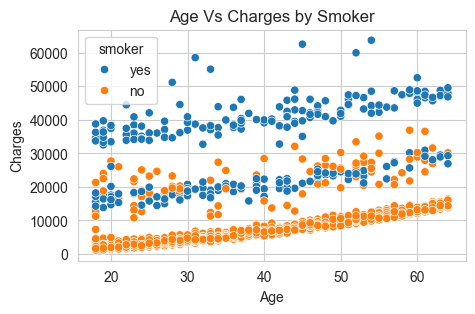

In [51]:
plt.figure(figsize=(5,3))
sns.scatterplot(x=df["age"], y=df["charges"], hue=df["smoker"])
plt.title("Age Vs Charges by Smoker")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

- Slight increase in charges with Age
- clear cluster showing high charges for smokers with Age

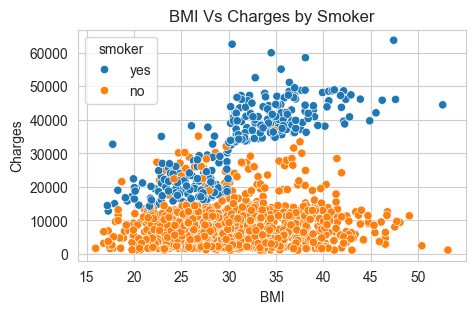

In [52]:
plt.figure(figsize=(5,3))
sns.scatterplot(x=df["bmi"], y=df["charges"], hue=df["smoker"])
plt.title("BMI Vs Charges by Smoker")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

- high charges for smokers with high bmi

### 7. Outliers Detection

In [53]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


In [54]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [55]:
print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)


Numerical Columns: ['age', 'bmi', 'children', 'charges']
Categorical Columns: ['sex', 'smoker', 'region']


**Detecting Outliers**

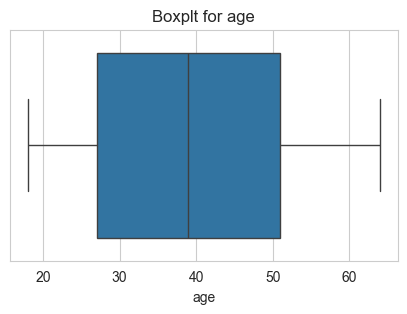

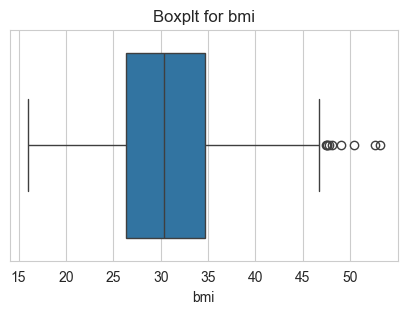

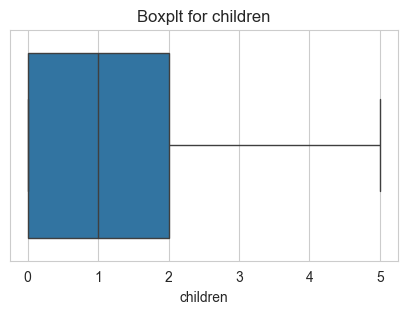

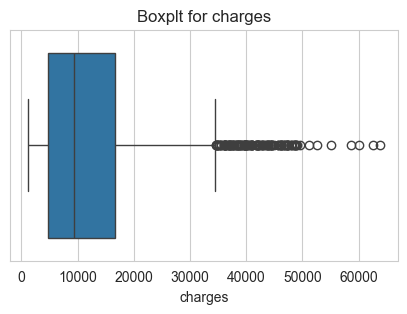

In [56]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplt for {col}")
    plt.xlabel(col)
    plt.show(    )

- BMI columns has some Outliers (feature column)
- charges columns has several Outliers(target column)

**IQR Method**

In [58]:
def iqr_bounds(series, factor=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - factor * iqr
    upper_bound = q3 + factor * iqr
    return lower_bound, upper_bound, iqr

In [60]:
for col in num_cols:
    col_clean = df[col].dropna()
    lower, upper, iqr = iqr_bounds(col_clean)
    outliers_mask = (col_clean < lower) | (col_clean > upper)
    num_outliers = outliers_mask.sum()
    total = col_clean.shape[0]

    print(f"\nIQR method for {col}")
    print(f"Q1 - 1.5*IQR: {lower:.2f}")
    print(f"Q3 + 1.5*IQR: {upper:.2f}")
    print(f"IQR: {iqr:.2f}")
    print(f"Outliers: {num_outliers} out of {total}")


IQR method for age
Q1 - 1.5*IQR: -9.00
Q3 + 1.5*IQR: 87.00
IQR: 24.00
Outliers: 0 out of 1338

IQR method for bmi
Q1 - 1.5*IQR: 13.70
Q3 + 1.5*IQR: 47.29
IQR: 8.40
Outliers: 9 out of 1338

IQR method for children
Q1 - 1.5*IQR: -3.00
Q3 + 1.5*IQR: 5.00
IQR: 2.00
Outliers: 0 out of 1338

IQR method for charges
Q1 - 1.5*IQR: -13109.15
Q3 + 1.5*IQR: 34489.35
IQR: 11899.63
Outliers: 139 out of 1338


**Z-score Method**

In [62]:
z_threshold = 3.0

for col in num_cols:
    col_clean = df[col].dropna()
    mean = col_clean.mean()
    std = col_clean.std()

    z_scores = (col_clean - mean) / std
    outliers_mask = np.abs(z_scores) > z_threshold
    num_outliers = outliers_mask.sum()
    total = col_clean.shape[0]

    print(f"\nZ Score metod for {col}")
    print(f"Mean: {mean:.2f}, std: {std:.2f}")
    print(f"Threshold: [Z] > {z_threshold}")
    print(f"Outliers: {num_outliers} out of {total}")


Z Score metod for age
Mean: 39.21, std: 14.05
Threshold: [Z] > 3.0
Outliers: 0 out of 1338

Z Score metod for bmi
Mean: 30.66, std: 6.10
Threshold: [Z] > 3.0
Outliers: 4 out of 1338

Z Score metod for children
Mean: 1.09, std: 1.21
Threshold: [Z] > 3.0
Outliers: 18 out of 1338

Z Score metod for charges
Mean: 13270.42, std: 12110.01
Threshold: [Z] > 3.0
Outliers: 7 out of 1338


- charges column is skewed and not in normal distribution and hence it's not ideal to use Z-score method to detect outliers for charges column

**Stat comparison after removing outliers in charges column**

Note: just for insight, shouldn't remove when model needs to be trained

In [64]:
charges_clean = df["charges"].dropna()
charges_lower, charges_upper, charges_iqr = iqr_bounds(charges_clean)

charges_inliers = charges_clean[(charges_clean >= charges_lower) & (charges_clean <= charges_upper)]

print("\nCharges stat with outliers:")
print(f"Count: {charges_clean.shape[0]}")
print(f"Mean: {charges_clean.mean():.2f}")
print(f"Median: {charges_clean.median():.2f}")
print(f"Min: {charges_clean.min():.2f}, Max: {charges_clean.max():.2f}")

print("*"*50)

print("\nCharges stat after removing IQR Outliers:")
print(f"Count: {charges_inliers.shape[0]}")
print(f"Mean: {charges_inliers.mean():.2f}")
print(f"Median: {charges_inliers.median():.2f}")
print(f"Min: {charges_inliers.min():.2f}, Max: {charges_inliers.max():.2f}")


Charges stat with outliers:
Count: 1338
Mean: 13270.42
Median: 9382.03
Min: 1121.87, Max: 63770.43
**************************************************

Charges stat after removing IQR Outliers:
Count: 1199
Mean: 9927.75
Median: 8410.05
Min: 1121.87, Max: 34472.84
